In [17]:
# 1. ЗАВАНТАЖЕННЯ ОЧИЩЕНОГО ФАЙЛУ

file_path = "cleaned_research_expenses.csv"

df = pd.read_csv(file_path)

print("Дані успішно завантажено!")
print("Кількість рядків:", df.shape[0])
print("Кількість колонок:", df.shape[1])

display(df.head())

Дані успішно завантажено!
Кількість рядків: 136
Кількість колонок: 21


,Показник,Територіальний розріз,Категорія розрізу,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки набору даних,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Витрати на наукові дослідження і розробки,Україна,Види витрат,Усього,Річна,Гривня,Тисячі,Один,NaN,1. Розрахунок показників темпів зростання/зниж...,...,NaN,NaN,NaN,NaN,NaN,20973775.2,17117836.2,21348062.6,28328170.6,NaN
1,Витрати на наукові дослідження і розробки,Україна,Галузі наук,Усього,Річна,Гривня,Тисячі,Один,NaN,1. Розрахунок показників темпів зростання/зниж...,...,NaN,NaN,NaN,17254629.7,17022419.3,20973775.2,17117836.2,21348062.6,28328170.6,NaN
2,Витрати на наукові дослідження і розробки,Україна,Джерела фінансування,Усього,Річна,Гривня,Тисячі,Один,Конфіденційна статистична інформація,1. Розрахунок показників темпів зростання/зниж...,...,NaN,NaN,NaN,17254629.7,17022419.3,NaN,17117836.2,21348062.6,28328170.6,NaN
3,Витрати на наукові дослідження і розробки,Україна,Види досліджень і розробок,Усього,Річна,Гривня,Тисячі,Один,NaN,1. Розрахунок показників темпів зростання/зниж...,...,NaN,13379292.4,16773724.5,17254629.7,17022419.3,20973775.2,17117836.2,21348062.6,28328170.6,NaN
4,Витрати на наукові дослідження і розробки,Вінницька,Види досліджень і розробок,Усього,Річна,Гривня,Тисячі,Один,NaN,1. Розрахунок показників темпів зростання/зниж...,...,NaN,NaN,NaN,39618.3,50756.2,NaN,NaN,NaN,NaN,NaN


In [18]:
# 2. ПЕРЕВІРКА КОЛОНОК

print("Назви колонок:")

for col in df.columns:
    print(col)

Назви колонок:
Показник
Територіальний розріз
Категорія розрізу
Вид економічної діяльності
Періодичність
Одиниця виміру
Масштабування
Кількість десяткових знаків
Спеціальне значення даних
Примітки набору даних
Примітки спостереження
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


In [19]:
# 3. ВИБІР КОЛОНОК З РОКАМИ 2016–2025

year_columns = [
    str(year)
    for year in range(2016, 2026)
    if str(year) in df.columns
]

print("Знайдені роки:")
print(year_columns)

Знайдені роки:
['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [20]:
# 4. ОПИСОВА СТАТИСТИКА


descriptive_stats = df[year_columns].describe().T

descriptive_stats = descriptive_stats.rename(columns={
    "count": "Кількість",
    "mean": "Середнє",
    "std": "Стандартне відхилення",
    "min": "Мінімум",
    "25%": "Q1 (25%)",
    "50%": "Медіана",
    "75%": "Q3 (75%)",
    "max": "Максимум"
})

descriptive_stats = descriptive_stats.round(2)

print("ОПИСОВА СТАТИСТИКА ЗА 2016–2025 РОКИ")

display(descriptive_stats)

ОПИСОВА СТАТИСТИКА ЗА 2016–2025 РОКИ


,Кількість,Середнє,Стандартне відхилення,Мінімум,Q1 (25%),Медіана,Q3 (75%),Максимум
2016,25.0,461227.90,1083445.64,9327.1,21360.50,55845.00,264845.50,4991777.9
2017,27.0,1486588.04,3630188.41,13244.9,28715.50,73601.90,357671.15,13379292.4
2018,27.0,1863747.17,4578692.63,16235.9,42397.55,87928.10,418792.20,16773724.5
2019,104.0,1327279.21,3620020.11,9948.3,32503.10,62130.15,417736.00,17254629.7
2020,96.0,1356360.93,3773414.12,9994.2,34615.28,78614.50,326873.92,17022419.3
2021,96.0,1667562.88,4731415.72,11303.4,40682.98,98368.80,368365.00,20973775.2
2022,89.0,1660099.81,4371221.36,10700.0,36009.60,83428.30,285042.70,17299525.9
2023,86.0,2176707.07,5500661.99,8743.0,44918.00,111102.10,319401.90,22706834.3
2024,93.0,2644507.67,7043656.62,11059.4,30799.90,124744.20,462122.60,28507986.6
2025,23.0,2889397.89,8187985.30,13917.0,53308.00,147482.90,431785.10,34653554.4


In [21]:
# 5. ПРОПУЩЕНІ ЗНАЧЕННЯ ЗА РОКАМИ

missing_stats = pd.DataFrame({
    "Кількість значень": df[year_columns].count(),
    "Кількість пропусків": df[year_columns].isna().sum(),
    "Пропуски, %": (
        df[year_columns].isna().mean() * 100
    ).round(2)
})

display(missing_stats)

,Кількість значень,Кількість пропусків,"Пропуски, %"
2016,25,111,81.62
2017,27,109,80.15
2018,27,109,80.15
2019,104,32,23.53
2020,96,40,29.41
2021,96,40,29.41
2022,89,47,34.56
2023,86,50,36.76
2024,93,43,31.62
2025,23,113,83.09


In [22]:
# 6. СЕРЕДНЄ ТА МЕДІАНА

central_tendency = pd.DataFrame({
    "Середнє": df[year_columns].mean(),
    "Медіана": df[year_columns].median()
})

central_tendency = central_tendency.round(2)

display(central_tendency)

,Середнє,Медіана
2016,461227.90,55845.00
2017,1486588.04,73601.90
2018,1863747.17,87928.10
2019,1327279.21,62130.15
2020,1356360.93,78614.50
2021,1667562.88,98368.80
2022,1660099.81,83428.30
2023,2176707.07,111102.10
2024,2644507.67,124744.20
2025,2889397.89,147482.90


In [23]:
print(df.columns.tolist())

['Показник', 'Територіальний розріз', 'Категорія розрізу', 'Вид економічної діяльності', 'Періодичність', 'Одиниця виміру', 'Масштабування', 'Кількість десяткових знаків', 'Спеціальне значення даних', 'Примітки набору даних', 'Примітки спостереження', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [24]:
print(df["Показник"].unique())

['Витрати на наукові дослідження і розробки']


In [25]:
print(df["Одиниця виміру"].value_counts(dropna=False))

Одиниця виміру
Гривня    136
Name: count, dtype: int64


In [26]:
# ОПИСОВА СТАТИСТИКА ВИТРАТ НА НАУКОВІ ДОСЛІДЖЕННЯ


year_columns = [
    str(year)
    for year in range(2016, 2026)
    if str(year) in df.columns
]

descriptive_stats = df[year_columns].describe().T

descriptive_stats = descriptive_stats.rename(columns={
    "count": "Кількість",
    "mean": "Середнє",
    "std": "Стандартне відхилення",
    "min": "Мінімум",
    "25%": "Q1 (25%)",
    "50%": "Медіана",
    "75%": "Q3 (75%)",
    "max": "Максимум"
})

descriptive_stats = descriptive_stats.round(2)

print("Описова статистика витрат на наукові дослідження і розробки, грн")

display(descriptive_stats)

Описова статистика витрат на наукові дослідження і розробки, грн


,Кількість,Середнє,Стандартне відхилення,Мінімум,Q1 (25%),Медіана,Q3 (75%),Максимум
2016,25.0,461227.90,1083445.64,9327.1,21360.50,55845.00,264845.50,4991777.9
2017,27.0,1486588.04,3630188.41,13244.9,28715.50,73601.90,357671.15,13379292.4
2018,27.0,1863747.17,4578692.63,16235.9,42397.55,87928.10,418792.20,16773724.5
2019,104.0,1327279.21,3620020.11,9948.3,32503.10,62130.15,417736.00,17254629.7
2020,96.0,1356360.93,3773414.12,9994.2,34615.28,78614.50,326873.92,17022419.3
2021,96.0,1667562.88,4731415.72,11303.4,40682.98,98368.80,368365.00,20973775.2
2022,89.0,1660099.81,4371221.36,10700.0,36009.60,83428.30,285042.70,17299525.9
2023,86.0,2176707.07,5500661.99,8743.0,44918.00,111102.10,319401.90,22706834.3
2024,93.0,2644507.67,7043656.62,11059.4,30799.90,124744.20,462122.60,28507986.6
2025,23.0,2889397.89,8187985.30,13917.0,53308.00,147482.90,431785.10,34653554.4


In [27]:
# ОСНОВНІ СТАТИСТИЧНІ ПОКАЗНИКИ ЗА РОКАМИ

summary = pd.DataFrame({
    "Середнє": df[year_columns].mean(),
    "Медіана": df[year_columns].median(),
    "Мінімум": df[year_columns].min(),
    "Максимум": df[year_columns].max()
}).round(2)

display(summary)

,Середнє,Медіана,Мінімум,Максимум
2016,461227.90,55845.00,9327.1,4991777.9
2017,1486588.04,73601.90,13244.9,13379292.4
2018,1863747.17,87928.10,16235.9,16773724.5
2019,1327279.21,62130.15,9948.3,17254629.7
2020,1356360.93,78614.50,9994.2,17022419.3
2021,1667562.88,98368.80,11303.4,20973775.2
2022,1660099.81,83428.30,10700.0,17299525.9
2023,2176707.07,111102.10,8743.0,22706834.3
2024,2644507.67,124744.20,11059.4,28507986.6
2025,2889397.89,147482.90,13917.0,34653554.4


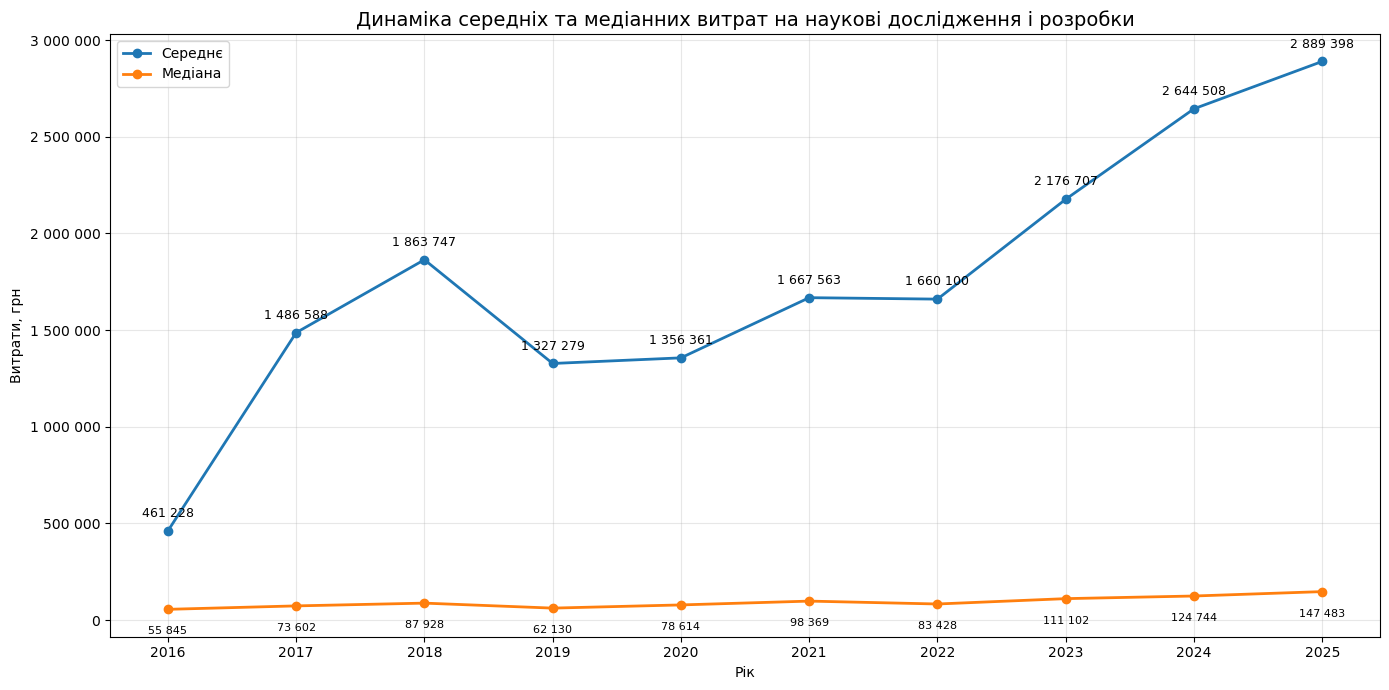

In [41]:

# ВІЗУАЛІЗАЦІЯ СЕРЕДНІХ ТА МЕДІАННИХ ВИТРАТ


import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(14, 7))

# Середнє
plt.plot(
    summary.index,
    summary["Середнє"],
    marker="o",
    linewidth=2,
    label="Середнє"
)

# Медіана
plt.plot(
    summary.index,
    summary["Медіана"],
    marker="o",
    linewidth=2,
    label="Медіана"
)



for year, value in summary["Середнє"].items():
    plt.annotate(
        f"{value:,.0f}".replace(",", " "),
        (year, value),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9
    )



for year, value in summary["Медіана"].items():
    plt.annotate(
        f"{value:,.0f}".replace(",", " "),
        (year, value),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center",
        fontsize=8
    )



plt.title(
    "Динаміка середніх та медіанних витрат "
    "на наукові дослідження і розробки",
    fontsize=14
)

plt.xlabel("Рік")
plt.ylabel("Витрати, грн")


plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:,.0f}".replace(",", " ")
    )
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

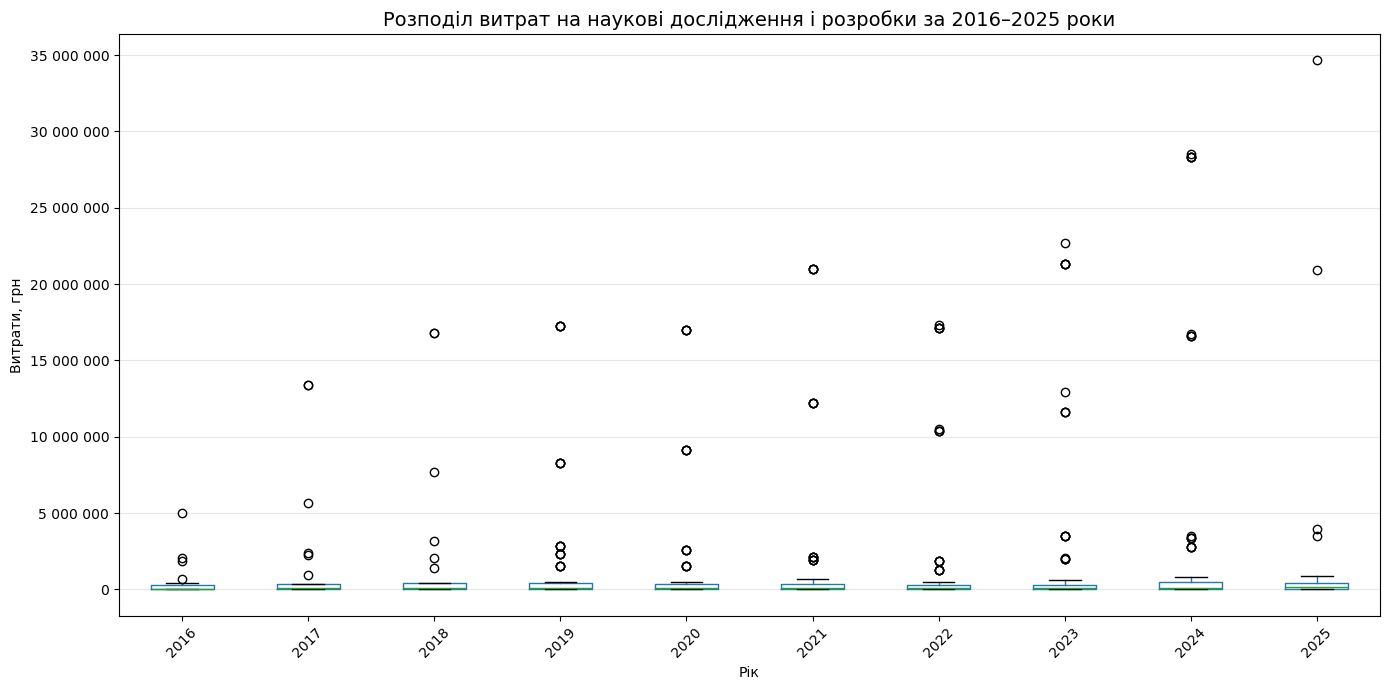

In [42]:
# BOXPLOT — АНАЛІЗ РОЗПОДІЛУ ТА ВИКИДІВ


import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ============================================================
# BOXPLOT — АНАЛІЗ РОЗПОДІЛУ ТА ВИКИДІВ
# ============================================================

plt.figure(figsize=(14, 7))

# Побудова boxplot
df[year_columns].boxplot(
    grid=False
)

# ------------------------------------------------------------
# Оформлення
# ------------------------------------------------------------

plt.title(
    "Розподіл витрат на наукові дослідження і розробки "
    "за 2016–2025 роки",
    fontsize=14
)

plt.xlabel("Рік")
plt.ylabel("Витрати, грн")

# Показуємо повні значення:
# 500000 замість 0.5 + 1e6
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:,.0f}".replace(",", " ")
    )
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [34]:
# ТЕМП ЗМІНИ СЕРЕДНІХ ВИТРАТ

growth = summary["Середнє"].pct_change() * 100

growth = growth.round(2)

growth_table = pd.DataFrame({
    "Середні витрати, грн": summary["Середнє"],
    "Зміна до попереднього року, %": growth
})

display(growth_table)

,"Середні витрати, грн","Зміна до попереднього року, %"
2016,461227.90,NaN
2017,1486588.04,222.31
2018,1863747.17,25.37
2019,1327279.21,-28.78
2020,1356360.93,2.19
2021,1667562.88,22.94
2022,1660099.81,-0.45
2023,2176707.07,31.12
2024,2644507.67,21.49
2025,2889397.89,9.26


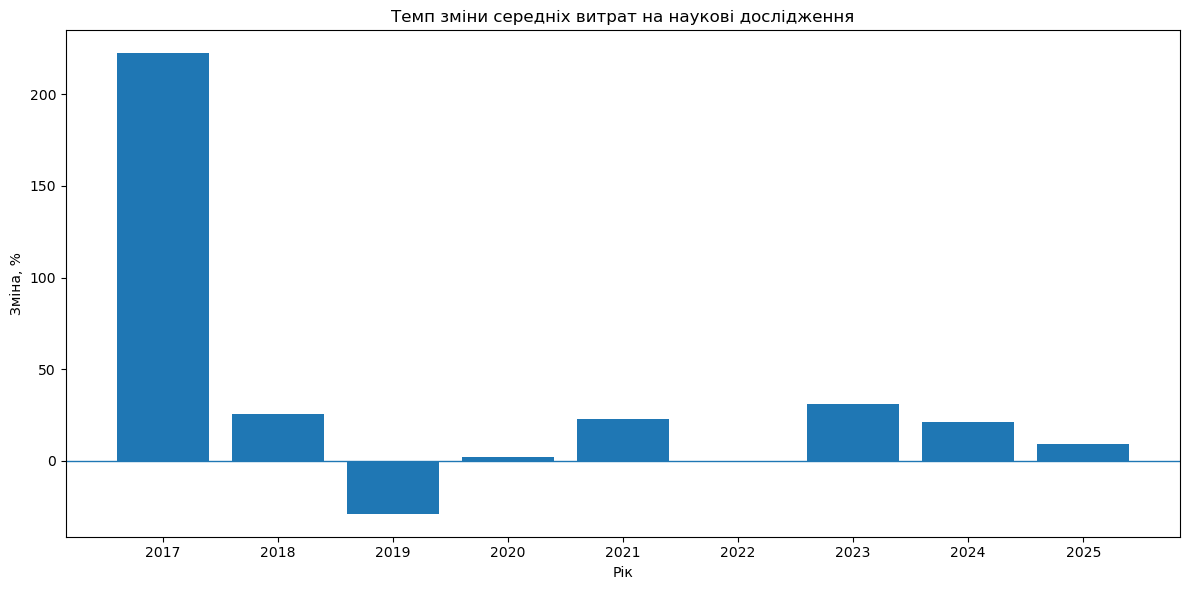

In [35]:
plt.figure(figsize=(12, 6))

plt.bar(
    growth.index,
    growth.values
)

plt.axhline(0, linewidth=1)

plt.title("Темп зміни середніх витрат на наукові дослідження")
plt.xlabel("Рік")
plt.ylabel("Зміна, %")

plt.tight_layout()
plt.show()

In [36]:
# КОРЕЛЯЦІЙНА МАТРИЦЯ

correlation_matrix = df[year_columns].corr()

display(correlation_matrix.round(2))

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
2016,1.00,1.00,0.99,0.99,0.98,0.96,0.95,0.97,0.97,0.96
2017,1.00,1.00,1.00,1.00,1.00,0.99,0.99,0.99,0.99,0.98
2018,0.99,1.00,1.00,1.00,1.00,0.99,0.99,0.99,0.99,0.99
2019,0.99,1.00,1.00,1.00,1.00,0.99,0.99,1.00,1.00,0.99
2020,0.98,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
2021,0.96,0.99,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00
2022,0.95,0.99,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00
2023,0.97,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00
2024,0.97,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00
2025,0.96,0.98,0.99,0.99,1.00,1.00,1.00,1.00,1.00,1.00


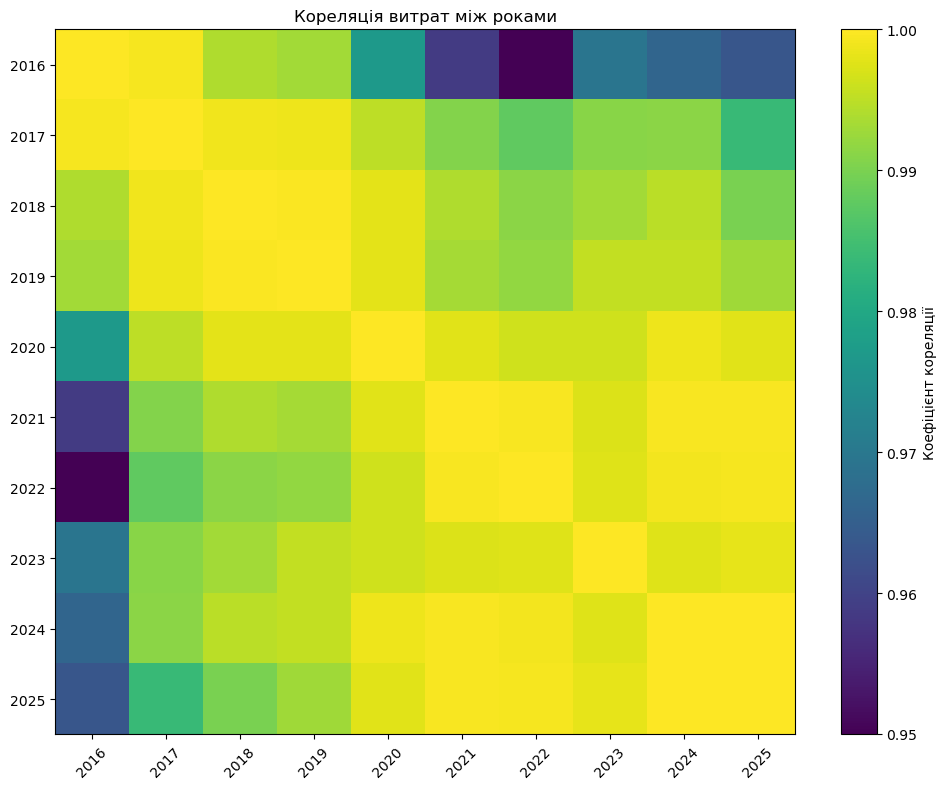

In [37]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Коефіцієнт кореляції")

plt.xticks(
    range(len(year_columns)),
    year_columns,
    rotation=45
)

plt.yticks(
    range(len(year_columns)),
    year_columns
)

plt.title("Кореляція витрат між роками")

plt.tight_layout()
plt.show()

In [38]:
start = summary.loc["2016", "Середнє"]
end = summary.loc["2025", "Середнє"]

total_growth = ((end - start) / start) * 100

print(
    f"Зміна середніх витрат з 2016 до 2025 року: "
    f"{total_growth:.2f}%"
)

Зміна середніх витрат з 2016 до 2025 року: 526.46%
